In [2]:
from shutil import rmtree

In [3]:
from roboflow import Roboflow
import os

rf = Roboflow(api_key="xuNKGLHhJC4pYUC1uttb")

workspace = rf.workspace()   # use the workspace tied to the key
print("Workspace connected.")

project = workspace.project("insulator-defect-yysit-nf9lv")   # use exact project slug from URL
version = project.version(1)
dataset = version.download("yolov8", location="insulator_project")

print(dataset.location)

loading Roboflow workspace...
Workspace connected.
loading Roboflow project...
C:\Users\Abhishek\after_vision\insulator_project


In [4]:
from pathlib import Path

root = Path("insulator_project")
for split in ["train", "valid", "test"]:
    img_dir = root / split / "images"
    lbl_dir = root / split / "labels"
    print(split.upper())
    print(" images:", len(list(img_dir.glob("*.jpg"))) + len(list(img_dir.glob("*.png"))))
    print(" labels:", len(list(lbl_dir.glob("*.txt"))))
    print()

TRAIN
 images: 1296
 labels: 1296

VALID
 images: 144
 labels: 144

TEST
 images: 160
 labels: 160



In [5]:
from PIL import Image
import numpy as np

img_dir = root / "train" / "images"
sizes = []
for p in list(img_dir.glob("*.jpg"))[:500]:   # sample up to 500
    w, h = Image.open(p).size
    sizes.append((w, h))

sizes = np.array(sizes)
print("mean (w, h):", sizes.mean(axis=0))
print("min (w, h):", sizes.min(axis=0))
print("max (w, h):", sizes.max(axis=0))

mean (w, h): [4556.96  3066.848]
min (w, h): [2136 1424]
max (w, h): [6000 4000]


In [6]:
import yaml
from collections import Counter

with open(root / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)

names = data_cfg["names"]
print("Classes:", names)

counter = Counter()
lbl_dir = root / "train" / "labels"
for p in lbl_dir.glob("*.txt"):
    with open(p) as f:
        for line in f:
            cls_id = int(line.split()[0])
            counter[cls_id] += 1

for cls_id, cnt in counter.items():
    print(f"{cls_id} ({names[cls_id]}): {cnt}")

Classes: ['broken', 'insulator', 'pollution-flashover']
1 (insulator): 1481
0 (broken): 867
2 (pollution-flashover): 1993


In [7]:
from ultralytics import YOLO

In [7]:
model26 = YOLO("yolo26n.pt")

In [8]:
model11 = YOLO("yolo11n.pt")

In [6]:
model8 = YOLO("yolov8n.pt")

In [10]:
model26.train(
    data="insulator_project\\data.yaml",
    epochs=50,
    imgsz=800, 
    batch=16,
    workers=4,
    device=0,
    cache=False,
    name = 'insulator_y26',
    patience=20
)

Ultralytics 8.4.50  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=insulator_project\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=insulator_y26, nbs=64, nms=False, opset=None, optimize=False, optimizer=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000274AF4E1C50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [11]:
model26.val(data = 'insulator_project\\data.yaml')

Ultralytics 8.4.50  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1963.4253.9 MB/s, size: 966.7 KB)
val: Scanning C:\Users\Abhishek\after_vision\insulator_project\valid\labels.cache... 144 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 144/144  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.9it/s 4.8s0.2ss
                   all        144        490      0.929       0.84      0.905       0.62
                broken         75         96      0.952      0.812      0.892      0.532
             insulator        144        164      0.972      0.994      0.995      0.961
   pollution-flashover         68        230      0.861      0.713      0.828      0.365
Speed: 2.1ms preprocess, 5.8ms inference, 0.0ms loss, 0.3ms postprocess per 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000273AB6057D0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [12]:
model11.train(
    data="insulator_project\\data.yaml",
    epochs=50,
    imgsz=800, 
    batch=16,
    workers=4,
    device=0,
    cache=False,
    name = 'insulator_y11',
    patience=20
)

Ultralytics 8.4.50  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=insulator_project\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=insulator_y11, nbs=64, nms=False, opset=None, optimize=False, optimizer=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000273ABE9F190>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [13]:
model11.val(data = 'insulator_project\\data.yaml')

Ultralytics 8.4.50  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 2597.8311.6 MB/s, size: 923.7 KB)
val: Scanning C:\Users\Abhishek\after_vision\insulator_project\valid\labels.cache... 144 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 144/144  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.8it/s 5.0s0.2ss
                   all        144        490      0.946      0.873       0.92      0.629
                broken         75         96      0.934      0.888      0.924      0.552
             insulator        144        164      0.996          1      0.995      0.949
   pollution-flashover         68        230      0.908      0.731       0.84      0.384
Speed: 2.2ms preprocess, 4.5ms inference, 0.0ms loss, 1.9ms postprocess per 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002716F7E57D0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [7]:
model8.train(
    data="insulator_project\\data.yaml",
    epochs=50,
    imgsz=800, 
    batch=16,
    workers=4,
    device=0,
    cache=False,
    name = 'insulator_y8',
    patience = 20
)

Ultralytics 8.4.50  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=insulator_project\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=insulator_y8-2, nbs=64, nms=False, opset=None, optimize=False, optimizer

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F7290C5010>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [8]:
model8.val(data = 'insulator_project\\data.yaml')

Ultralytics 8.4.50  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 2090.2200.4 MB/s, size: 966.7 KB)
val: Scanning C:\Users\Abhishek\after_vision\insulator_project\valid\labels.cache... 144 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 144/144  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.0it/s 4.6s0.2ss
                   all        144        490      0.935      0.858      0.916      0.626
                broken         75         96      0.908      0.865      0.908      0.531
             insulator        144        164      0.993          1      0.995      0.953
   pollution-flashover         68        230      0.903      0.709      0.844      0.394
Speed: 1.5ms preprocess, 4.8ms inference, 0.0ms loss, 1.8ms postprocess per ima

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F72F229BD0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [30]:
#the weights have since been moved to new dierctory

In [31]:
model8 = YOLO('runs\\detect\\insulator_y8\\weights\\v8_best.pt')

In [32]:
model11 = YOLO('runs\\detect\\insulator_y11\\weights\\v11_best.pt')

In [33]:
model26 = YOLO('runs\\detect\\insulator_y26\\weights\\v26_best.pt')

In [12]:
data_yaml = "insulator_project\\data.yaml"

In [13]:
models_dict = {
    "YOLOv8n": model8,
    "YOLOv11n": model11,
    "YOLOv26n": model26
}

In [15]:
results_data=[]
for name, model in models_dict.items():
    print(f"\n--- Evaluating {name} on TEST set ---")

    metrics = model.val(data=data_yaml, split="test", imgsz=800, device=0, plots=False)

    m_dict = metrics.results_dict

    precision = m_dict.get('metrics/precision(B)', 0.0)
    recall = m_dict.get('metrics/recall(B)', 0.0)
    map50 = m_dict.get('metrics/mAP50(B)', 0.0)
    map50_95 = m_dict.get('metrics/mAP50-95(B)', 0.0)
    
    results_data.append({
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "mAP50": round(map50, 4),
        "mAP50-95": round(map50_95, 4)
    })


--- Evaluating YOLOv8n on TEST set ---
Ultralytics 8.4.50  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 2132.0299.9 MB/s, size: 1096.4 KB)
val: Scanning C:\Users\Abhishek\after_vision\insulator_project\test\labels.cache... 160 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 160/160  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.9it/s 5.1s.1s
                   all        160        542      0.907      0.897      0.923      0.622
                broken         85        130      0.858      0.927      0.932      0.524
             insulator        160        187      0.992          1       0.99      0.945
   pollution-flashover         80        225      0.873      0.763      0.847      0.398
Speed: 1.4ms preprocess, 3.0ms inference, 0.0ms loss, 1.1ms postprocess per image

--- Evaluating YOLOv11n on TEST set 

In [17]:
import pandas as pd

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df_comparison = pd.DataFrame(results_data)
df_comparison.set_index("Model", inplace=True)

print("\n--- FINAL TEST SET COMPARISON ---")
print(df_comparison)


--- FINAL TEST SET COMPARISON ---
          Precision  Recall   mAP50  mAP50-95
Model                                        
YOLOv8n      0.9075  0.8967  0.9232    0.6222
YOLOv11n     0.9266  0.8802  0.9312    0.6354
YOLOv26n     0.8901  0.8937  0.9173    0.6223


<Axes: title={'center': 'YOLO Performance Comparison'}, xlabel='Model'>

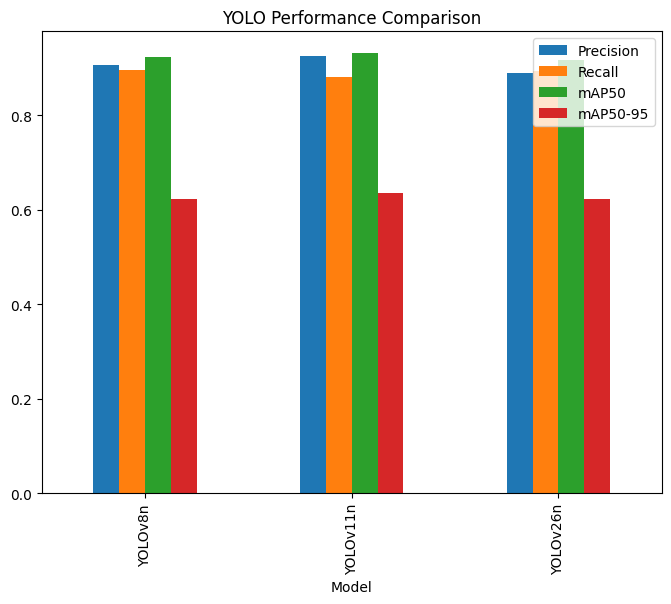

In [29]:
df_comparison.plot(kind='bar',figsize=(8,6), title="YOLO Performance Comparison")